<a href="https://colab.research.google.com/github/tagemehta/20.C01/blob/main/Copy_of_pset1_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <center> Problem Set 1 (MHC) <center>
<center> Spring 2025 <center>
<center> 3.C01/3.C51, 7.C01/7.C51, 10.C01/10.C51, 20.C01/20.C51 <center>
<center> Due: Monday, April 7, 2025 at 3:00 PM ET. <center>

<b>Name: Tage Mehta</b>

<b>Kerberos ID: 983987700</b>

# Learning outcomes for this problem set
In this problem set, you will:

- Learn the basics of processing your data and training a machine learning model with PyTorch:
    * Processing data, including exploring OHE vs. other featurization techniques
    * Formatting your data into a `Dataset` object and wrapping in a `DataLoader` instance
    * Implementation of a Multi-Layer Perception in `PyTorch`
    * Setting up a training and testing loop, and how to do evaluation
    * Using a GPU to accelerate training!
    * Find the best hyperparameters


- Learn how to build some simple architectures for **classification** and **regression**:
    * Train a logistic regression model with `scikit-learn` to _classify_ breast cancers based on metabolite abundance
    *  Train a random forest classifier on the same data
    * Train a MLP using `PyTorch` on the same data
    * Train a MLP with `PyTorch` to _regress_ binding affinities of antibodies from their sequences
    * Apply regularization techniques to avoid overfitting (L1 and L2)
    * Apply physical descriptor-based encoding to improve training performance


# Instructions

- This problem set has two modeling tasks with several sub-questions. Some are marked grad version, which are required for graduate students (X.C51) but optional for others. Points for all students are shown in <span style="color:blue">blue</span>, while grad-only points are shown in <span style="color:orange">orange</span>. Total points: 75 (undergraduates) / 100 (graduates).

- To get started, make your own copy of this notebook template in Colab (e.g., “Save a copy in Drive”) before editing.

    - Important: this problem set requires a GPU. In Google Colab go to `Edit -> Notebook settings` and set the `Hardware accelerator` to a GPU before running the notebook (changing the runtime resets the notebook). See the GPU section below for additional help.

- Collaboration is encouraged and AI tools are permitted, but submitting work that is not your own is plagiarism. Any collaboration or assistance from others or from an LLM (including utilities integrated in Colab) must be described at the end of your submission.

- Additional notes about how to use this template:
    - Put your code in the code blocks flagged with `############# Code ##########`.

    -  Numerical answers yielded from running the code should be included in an Answer Block (see next cell).

    - We have provided print statements where numerical answers are expected.

    -  Your answer should be contained in a variable which you defined either in the Answer Block or the Code Block.

    - When a qualitative answer is expected, place those comments as Markdown/Text cells; when asked for within Code blocks, you can write answer as code comments by placing a # before your answer.

- Submission: upload your completed `pset1.ipynb` to Gradescope. Ensure the notebook runs without error and includes all necessary code, plots, and outputs. Comments are encouraged; place conceptual answers in Markdown/Text cells.




# Imports, helper functions, and data

In [ ]:
# import packages
import numpy as np
import sklearn
import pandas as pd
from sklearn.model_selection import train_test_split

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from torch.utils.data import Dataset, DataLoader
from torch import nn
import torch.nn.functional as F

# metrics
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter("ignore", category=ConvergenceWarning)
import torch
from tqdm import tqdm


# plotting style, you can choose your own parameters
import matplotlib

matplotlib.rcParams.update({'font.size': 15})
matplotlib.rc('lines', linewidth=3, color='g')
matplotlib.rcParams['axes.linewidth'] = 2.0
matplotlib.rcParams['axes.linewidth'] = 2.0
matplotlib.rcParams["xtick.major.size"] = 6
matplotlib.rcParams["ytick.major.size"] = 6
matplotlib.rcParams["ytick.major.width"] = 2
matplotlib.rcParams["xtick.major.width"] = 2
matplotlib.rcParams['text.usetex'] = False

In [ ]:
# A helper function for students to produce plots
def plot_clf(model, X, y, title):

    '''
        A function to plot confusion matrix and ROC curve

        Args:
            model(classifier object): model object (e.g. RandomForestClassifier, LogisticRegression)
            X(np.array): feature set
            y(np.array): label set
            title(str): plot name

        Example Usage:
            plot_clf(model, X_test, y_test, "test")
    '''

    fig, [ax_roc, ax_conf] = plt.subplots(1, 2, figsize=(12, 6))
    fig.tight_layout()

    RocCurveDisplay.from_estimator(model, X, y, ax=ax_roc)
    ConfusionMatrixDisplay.from_estimator(model, X, y, ax=ax_conf)

    ax_roc.set_title('{} ROC'.format(title))
    ax_conf.set_title('{} Confusion Matrix'.format(title))

    plt.show()

In [ ]:
# for 1st set of tasks: binary classification
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/breastcancer_X.csv
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/breastcancer_y.csv

# for 2nd set of tasks: regression of binding affinities
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/data_mhc/amino_acid.csv
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/data_mhc/ba_train.csv
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/data_mhc/ba_holdout.csv
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/data_mhc/amino_acids.npy

--2026-04-06 01:31:34--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/breastcancer_X.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 469363 (458K) [text/plain]
Saving to: ‘breastcancer_X.csv’

breastcancer_X.csv  100%[===================>] 458.36K  --.-KB/s    in 0.04s   

2026-04-06 01:31:34 (12.7 MB/s) - ‘breastcancer_X.csv’ saved [469363/469363]

--2026-04-06 01:31:34--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/data/breastcancer_y.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting re

# Problem 1: Breast cancer classification from metabolite data

## Background
Imagine if all diseases could be diagnosed with from a tiny drop of
blood. While that day may still be far off, much progress has been made
in searching for what are called *biomarkers*, molecules in the blood
that are associated with particular diseases. Many studies use [mass
spectrometry](https://en.wikipedia.org/wiki/Mass_spectrometry) to search
for such diagnostic molecules. Biomarkers can be proteins, nucleic
acids, lipids, or any of thousands of other chemical compounds that are
found in the blood:

<figure>
<center>
<img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/figures/metabolites.png" width="450px">

<figcaption>Adapted from <a href="https://pubmed.ncbi.nlm.nih.gov/27451335/" target="_blank">Gonzalez et al. 2016</a></figcaption>
</center>
</figure>

Because many of these chemical compounds are products of metabolism,
they are often called *metabolites*, and the detection of metabolites is
called [metabolomics](https://en.wikipedia.org/wiki/Metabolomics).
Recent studies have shown that metabolites can be predictive of human
health conditions ([Bar et al. 2020](https://pubmed.ncbi.nlm.nih.gov/33177712/), [Evans et al. 2020](https://www.nature.com/articles/s41598-020-74823-1)). In this
problem, we will use two different classification methods to detect
breast cancer from patients' metabolite data collected from human
plasma/serum, following data processing steps from [Huang et al. 2016](https://pubmed.ncbi.nlm.nih.gov/27036109/) found
[here](https://www.metabolomicsworkbench.org/data/DRCCMetadata.php?Mode=Study&StudyID=ST000355).


## 1.1 <span style="color:blue">(5 points)</span> Load and inspect the raw data

To perform supervised machine learning on vector-valued data, you need labeled examples $\{(\mathbf{x},y)\}$, where $\mathbf{x}$ is a vector of input features and $y$ the known label. Your goal is to train a model $\hat{f}$ that maps features to labels: $\hat{f}(\mathbf{x}) \approx y$. For diagnosing breast cancer from metabolite data, the metabolite signal is $\mathbf{x}$, and the binary label (positive or negative) is $y$, both provided as `.csv` files.

**Task 1**: We provide code utilizing pandas and numpy to load the data. Make sure you understand what each line of code is doing. Briefly explain each line.

You will have to do it by yourself again in Problem 2.

In [ ]:
p1_X = pd.read_csv("./breastcancer_X.csv", header='infer', index_col=0) # Load csv file into a dataframe with the first column as the index
p1_y = pd.read_csv("./breastcancer_y.csv", header='infer', index_col=0) # X and Y are in seperate CSV files and loaded into their own df's

metabolite_name = p1_X.columns.tolist() # Take the headers and turn them into an array
p1_X = p1_X.values # Numpy array of X values
p1_y = p1_y.values # Numpy array of Y values

**Task 2**: Use `X.shape` to report the number of samples and features per sample. Report how many examples are in this dataset and the number of features for each data point.

In [ ]:
########## Code ############
N_samples = p1_X.shape[0]
N_features = p1_X.shape[1]

########## Code ############

print("There are {} samples.".format(N_samples))
print("There are {} features per sample.".format(N_features))

There are 211 samples.
There are 128 features per sample.


## 1.2 <span style="color:blue">(5 points)</span> Generate train/test splits.

To fairly evaluate the performance, split your data into a training data set and testing data set. Only training data should be used to train the model; testing data are for unbiased evaluations of model performance. During training, the model should not have access to *any* information about the testing dataset, so you should not train (or preprocess!) on the testing data.

**Task 1**: Use [sklearn.model_selection.train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to _randomly_ split your dataset into training and testing data with an **80%:20% ratio** (you should get two feature arrays, and two corresponding label arrays).

**Task 2**: Generate and print the shapes of your four variables, `X_train`, `X_test`, `y_train`, and `y_test`, and ensure that the dimensions match your expectations.

In [ ]:
########### Code #############
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(p1_X, p1_y, train_size=0.8, random_state=10)

X_train_shape = X_train.shape
y_train_shape = y_train.shape
X_test_shape = X_test.shape
y_test_shape = y_test.shape


print("X_train shape: {}".format(X_train_shape))
print("y_train shape: {}".format(y_train_shape))

print("X_test shape: {}".format(X_test_shape))
print("y_test shape: {}".format(y_test_shape))

########### Code #############

X_train shape: (168, 128)
y_train shape: (168, 1)
X_test shape: (43, 128)
y_test shape: (43, 1)


In [ ]:
########## Answer ############

X_train_shape = X_train.shape
y_train_shape = y_train.shape
X_test_shape = X_test.shape
y_test_shape = y_test.shape


print("X_train shape: {}".format(X_train_shape))
print("y_train shape: {}".format(y_train_shape))

print("X_test shape: {}".format(X_test_shape))
print("y_test shape: {}".format(y_test_shape))

########## Answer ############

X_train shape: (168, 128)
y_train shape: (168, 1)
X_test shape: (43, 128)
y_test shape: (43, 1)


## 1.3 <span style="color:blue">(5 points)</span> Preprocess the data through scaling
Features in your dataset may have different units and magnitudes (e.g., molecular weight vs. covalent radius). To avoid unfairly weighting features, we **standardize** all features to a consistent scale.

Let $N$ be the total number of features and $M$ be the total sample size. Let the feature vector for the $j$-th sample be $\{X_{0,j}, \ldots, X_{i,j}, \ldots, X_{N-1,j}\}$, where $X_{i,j}$ is the unnormalized abundance of the $i$-th metabolite in the $j$-th patient. The mean and variance of each feature are:

$$
\mu_i = \frac{1}{M}\sum_{j=1}^{M} X_{i,j}, \qquad
\sigma_i^2 = \frac{1}{M}\sum_{j=1}^{M} (X_{i,j} - \mu_i)^2
$$

Each feature is transformed by an affine (linear) mapping to produce the standardized feature $X'_{i,j}$:

$$
X'_{i,j} = \frac{1}{\sigma_i}\,(X_{i,j} - \mu_i)
$$

This transform is invertible (given $\mu_i$ and $\sigma_i$), so no information is lost.

Note: scikit-learn and numpy use normalization by M (population standard deviation) rather than M−1 (sample standard deviation); pandas defaults to the sample standard deviation.

**Task 1**: Use scikit-learn’s `preprocessing.StandardScaler` to process your input features `X` into `X_train_scaled` (see: https://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling). Apply the same transformation to `X_test` to produce  `X_test_scaled`.

In [ ]:
########### Code #############
train_scaler = preprocessing.StandardScaler().fit(X_train)
X_train_scaled = train_scaler.transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

########### Code #############

**Task 2**: Show the $\mu_i$ and $\sigma_i$ of each feature are 0 and 1 respectively after scaling.

In [ ]:
########## Code ############
train_mean = X_train_scaled.mean()
train_variance = X_train_scaled.var()
test_mean = X_test_scaled.mean()
test_variance = X_test_scaled.var()
########## Code ############

print("The means of the transformed feature train set are {}".format(train_mean) )
print("The variances of the transformed feature train set are {}".format(train_variance) )
print("The means of the transformed feature test set are {}".format(test_mean) )
print("The variances of the transformed feature test set are {}".format(test_variance) )

The means of the transformed feature train set are 1.3745618400120986e-16
The variances of the transformed feature train set are 1.0
The means of the transformed feature test set are -0.07713422119301498
The variances of the transformed feature test set are 1.0342166926808432


**Question**: In 1-3 sentences, describe why the ScalerTransform should _only_ be fit to `X_train` and applied to `X_test`; what information leak might occur if one were to fit the scaler on the entire dataset prior to splitting?

The train data should be fully independent of the test data, training the ScalerTransform on the aggregated data would affect the mean and variance and leak info from the test data, hurting your ability to test how the model generalizes and potentially overfitting to the training set.

## 1.4 <span style="color:blue">(10 points)</span> Training a logistic regression classifier with `scikit-learn`

Now, you should be ready to train a logistic regression model and evaluate its performance on the test data. We will use simple model modules from `scikit-learn`, a machine learning library. We will use three handy evaluations for this task:

- **Confusion matrices** ([reference](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)): A visualization to stratify model performance by looking at positive and negative samples separately, and how many are correctly classified (true positives and negatives) vs. misclassified (false positives and negatives).
- **ROC Curve** ([reference](https://en.wikipedia.org/wiki/Receiver_operating_characteristic)): The receiver operating characteristic (ROC) curve plots the true positive rate (TPR) against the false positive rate (FPR) at different decision thresholds. We usually report the area under the curve (AUC) of the ROC (AUC-ROC) for a scalar metric.
- **Precision–Recall (PR) curve** ([reference](https://en.wikipedia.org/wiki/Precision_and_recall)): This plots the precision (proportion of true positives to all predicted positives) against the recall (or true positive rate). We report the area under the PR curve (AUPRC) as a single metric from the PR curve. This evaluation is handy when the dataset is highly imbalanced, i.e., many more positives than negatives or vice versa.


**Task 1**: Train a logistic regression model on the scaled training data and evaluate it on testing data with scikit-learn's [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) class.

In [ ]:
########### Code #############
logistic_model = LogisticRegression(random_state=0).fit(X_train_scaled, y_train.ravel())

########### Code #############

**Task 2**: Report the AUC-ROC score for both the train and test datasets.

In [ ]:
########## Code ############
y_train_pred = logistic_model.predict(X_train_scaled)
train_auc = roc_auc_score(y_train, y_train_pred)

y_test_pred = logistic_model.predict(X_test_scaled)
test_auc = roc_auc_score(y_test, y_test_pred)
########## Code ############
print("The training AUC score is {:.3f}".format(train_auc) )
print("The testing AUC score is {:.3f}".format(test_auc) )

The training AUC score is 1.000
The testing AUC score is 0.952


**Task 3**: Generate plots for confusion matrices and the ROC curve with help of `plot_clf` for both the train and test datasets.

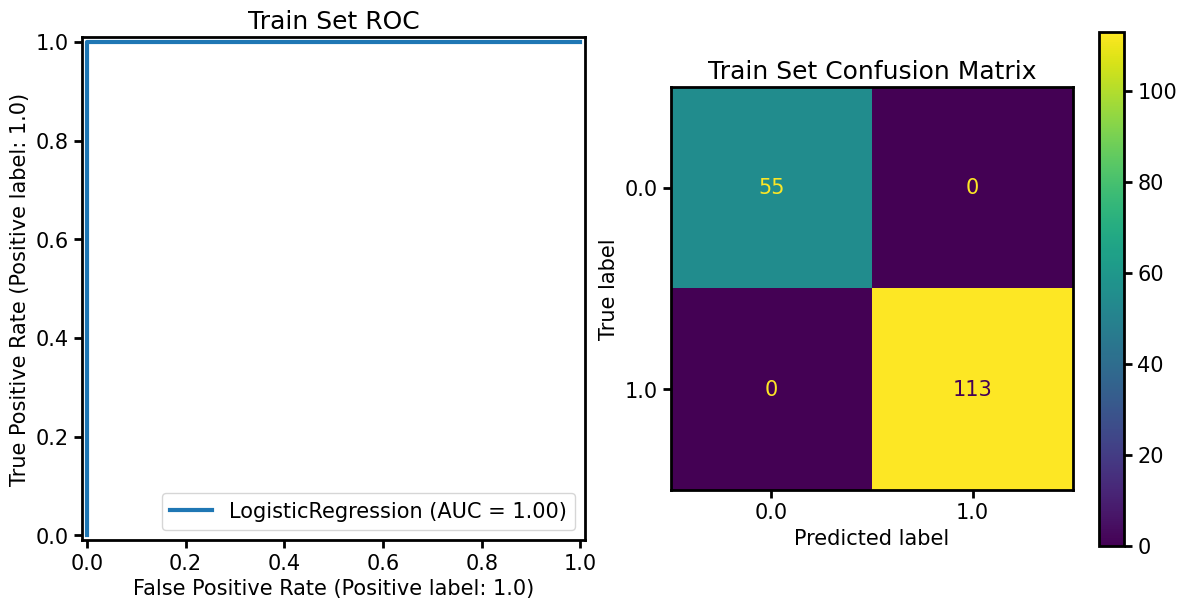

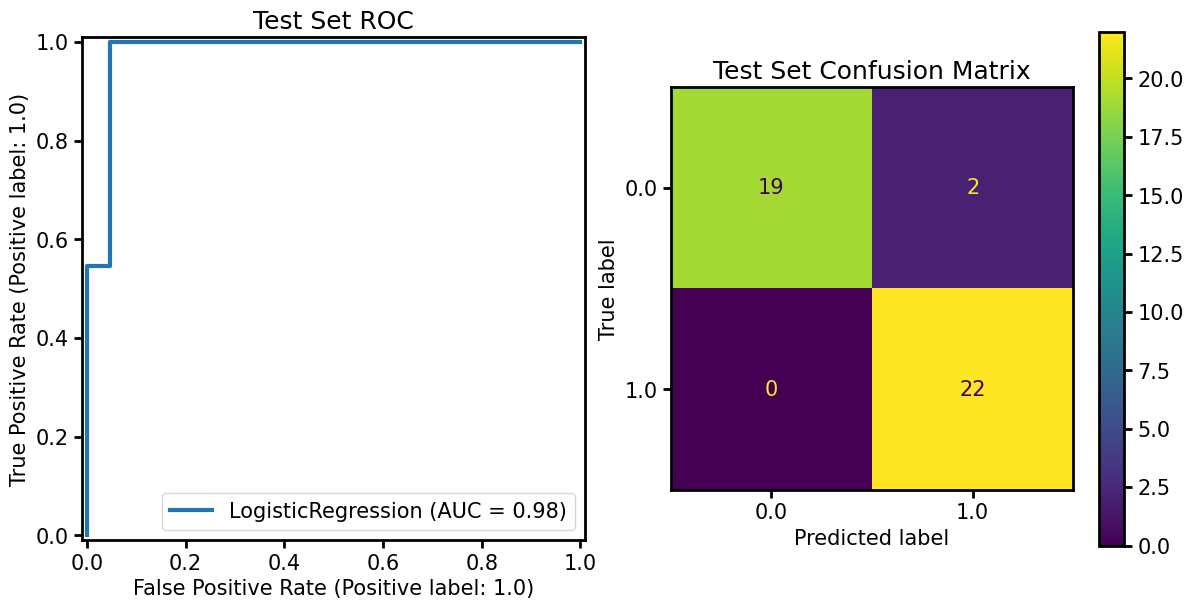

In [ ]:
########## Code ############
plot_clf(logistic_model, X_train_scaled, y_train, title="Train Set")
plot_clf(logistic_model, X_test_scaled, y_test, title="Test Set")
########## Code ############

**Task 4**: Finally, plot a histogram with [matplotlib.pyplot.hist](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) of the model coefficients (you can retrieve model coefficients from `model.coef_`, where `model` is your model) to get an understanding of the parameters learned for the dataset's features.

(array([ 4.,  0.,  1.,  3.,  2.,  2.,  2.,  8., 15., 21., 19., 17., 12.,
         7.,  5.,  1.,  3.,  2.,  2.,  2.]),
 array([-0.55960742, -0.50606915, -0.45253088, -0.39899261, -0.34545434,
        -0.29191607, -0.2383778 , -0.18483953, -0.13130126, -0.07776299,
        -0.02422472,  0.02931355,  0.08285182,  0.13639009,  0.18992836,
         0.24346663,  0.2970049 ,  0.35054317,  0.40408144,  0.45761971,
         0.51115798]),
 <BarContainer object of 20 artists>)

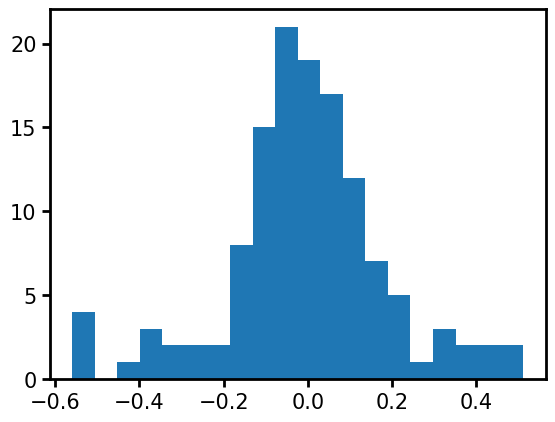

In [ ]:
########### Code #############
plt.hist(logistic_model.coef_.flatten(), bins=20)
# Coef shape (1, 128) so flatten
########### Code #############

## 1.5 <span style="color:blue">(5 points)</span> Introduce L1 regularization
In the previous part, you visualized the distribution of model coefficients. Now, we consider how these change after regularizing the model with L1 loss (we'll explore L2 regularization in Part 2).


**Task 1**: Modify your logistic regression model to include L1 regularization using the keyword arguments `penalty='l1'`, `solver=`saga'`. Use the same pre-processed training and testing data from above.

In [ ]:
########### Code #############
regularized_logistic_model =LogisticRegression(random_state=0, penalty="l1", solver="saga").fit(X_train_scaled, y_train.ravel())

########### Code #############

**Task 2**: Print the AUC-ROC score for both training and testing data.

In [ ]:
########### Code #############
########## Code ############
y_train_pred = regularized_logistic_model.predict(X_train_scaled)
train_auc = roc_auc_score(y_train, y_train_pred)

y_test_pred = regularized_logistic_model.predict(X_test_scaled)
test_auc = roc_auc_score(y_test, y_test_pred)

########### Code #############
print("The training AUC score is {:.2f}".format(train_auc) )
print("The testing AUC score is {:.2f}".format(test_auc) )

The training AUC score is 1.00
The testing AUC score is 0.95


**Task 3**: Plot the ROC curve and the confusion matrix for both training and testing data.

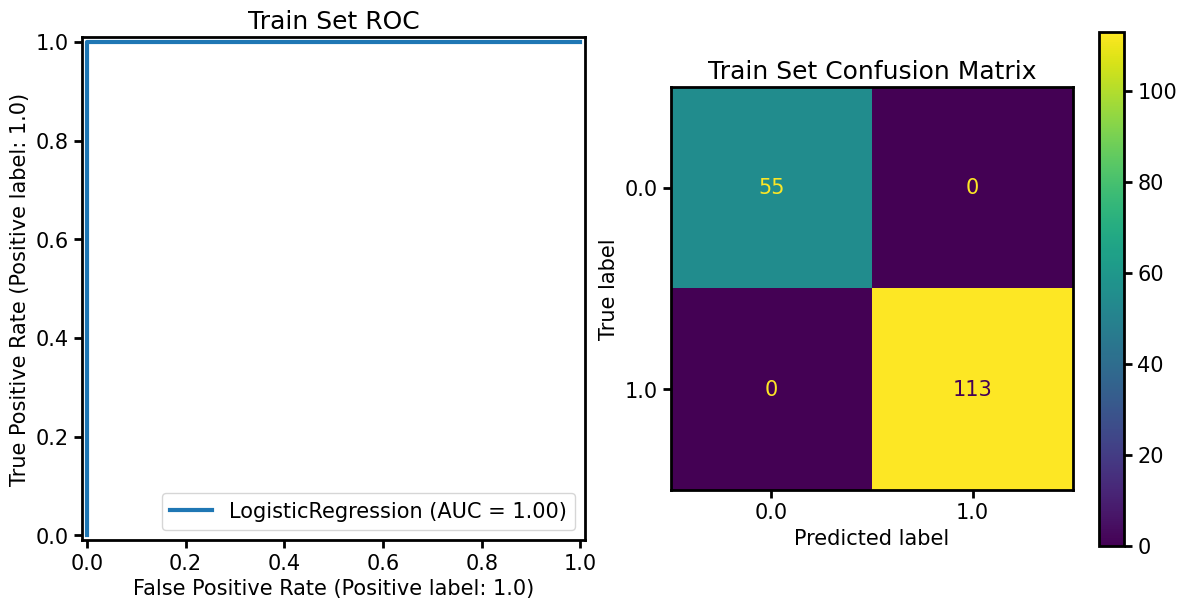

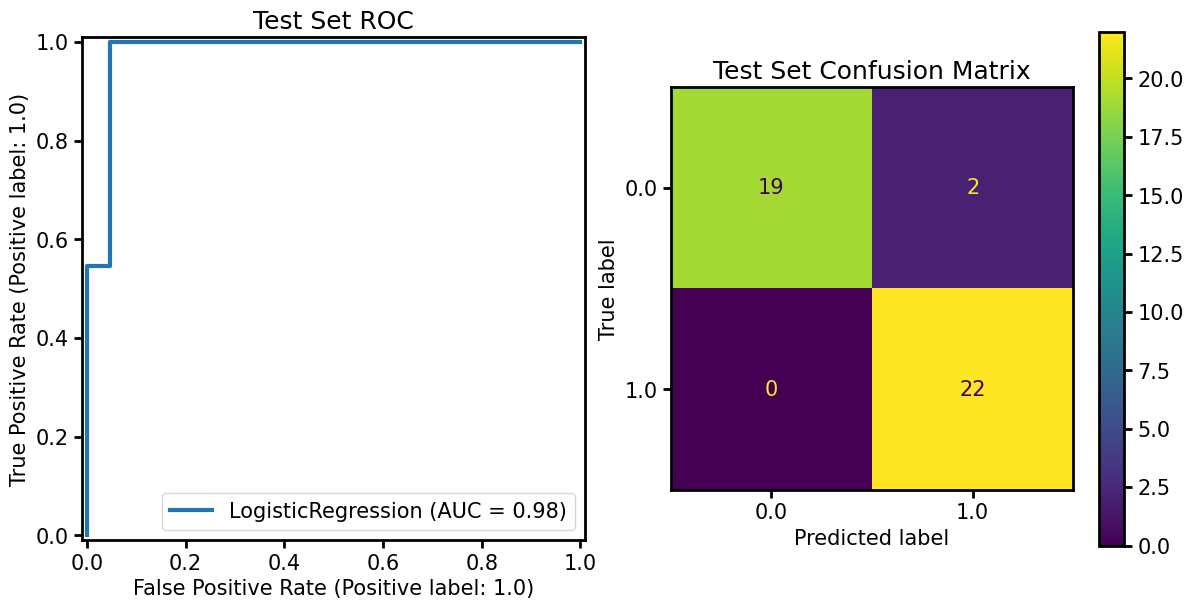

In [ ]:
########### Code #############
plot_clf(logistic_model, X_train_scaled, y_train, title="Train Set")
plot_clf(logistic_model, X_test_scaled, y_test, title="Test Set")
########### Code #############

**Task 4**: Probe the effect of regularization by plotting the histogram of the new model coefficients to find any qualitative changes.

(array([  1.,   0.,   1.,   0.,   1.,   1.,   2.,   2.,   0.,   2.,   0.,
        109.,   0.,   2.,   2.,   0.,   2.,   1.,   1.,   1.]),
 array([-0.96015935, -0.8758047 , -0.79145005, -0.7070954 , -0.62274075,
        -0.5383861 , -0.45403146, -0.36967681, -0.28532216, -0.20096751,
        -0.11661286, -0.03225821,  0.05209643,  0.13645108,  0.22080573,
         0.30516038,  0.38951503,  0.47386968,  0.55822432,  0.64257897,
         0.72693362]),
 <BarContainer object of 20 artists>)

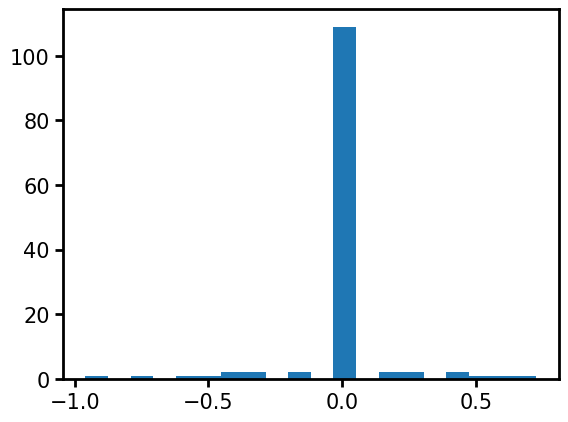

In [ ]:
########### Code #############
plt.hist(regularized_logistic_model.coef_.flatten(), bins=20)

########### Code #############

**Question**: Comment on any differences between the two models' distribution of model coefficients, thinking specifically about the _geometric_ interpretation of L1 regularization.

The vast majority of weights are about 0 in the regularized model as opposed to much more evenly distributed weights in the unregularized model

## 1.6  <span style="color:blue">(optional +2.5 points)</span> Connect model coefficients back to metabolites

**Task 1**: The column of your feature set $X$ which you loaded in Part 1.1 contains the chemical name for each metabolite. Based on the trained model you have just produced (with L1 regularization), identify the top 5 metabolites that are most correlated the most with a positive diagnosis.

> **Note**: in your own research, you would want to repeat this analysis for multiple random splits to see if the most important metabolites are consistent or whether the ones identified through this feature may be the result of spurious correlations.

In [ ]:
########### Code #############
ranked_metabolite_coeffs = pd.DataFrame({
    "metabolites": metabolite_name,
    "coeffs": regularized_logistic_model.coef_.flatten()
    }).sort_values(by="coeffs", ascending=False)

top5 = ranked_metabolite_coeffs["metabolites"][0:5]

########### Code #############

# note that `top5` is a list
print("The top 5 metabolites are {}".format(", ".join(top5)) )

The top 5 metabolites are 2-Butenedioic acid, L-Homoserine, 2,2'-Bipyridine, 1,2-dimethylpropanol, 2-aminobutyric acid


## 1.7 <span style="color:blue">(5 points)</span> Hyperparameter tuning the regularization parameter
To optimize your model further, one may tune the hyperparameters, which are parameters whose values are used to control some aspect of the model or the learning process, but is not optimized during the training. These might include the layer widths, the number of layers, the learning rate, optimizer, and more. This is done for a number of reasons: to prevent overfitting, make training most efficient, improve generalization, etc.


**Task 1**: For this problem, tune the regularization parameter by testing 4 values `C=[0.01, 1, 5, 10]` (in `scikit-learn`, the regularization parameter `C` is inversely related to the regularization strength), and selecting the best model based on the training set (or you may create a separate validation set, if desired). Report the hyperparameter with the best train performance, and that model's performance on the test set.

In [ ]:
best_value = None
best_metric = 0
C_values = [0.01, 1, 5, 10]

########### Code #############
best_model = None
for c in C_values:
  model = LogisticRegression(random_state=0, penalty="l1", solver="saga", C=c).fit(X_train_scaled, y_train.ravel())
  auc = roc_auc_score(y_train_pred, model.predict(X_train_scaled))
  if best_metric < auc:
    best_metric = auc
    best_value = c
    best_model = model

test_auc = roc_auc_score(y_test_pred, model.predict(X_test_scaled))


########### Code #############

In [ ]:
########### Answer #############

print(f"Best value: C = {best_value}")
print("The hyperparameterized model's test AUC score is {:.2f}".format(test_auc) )

########### Answer #############

Best value: C = 1
The hyperparameterized model's test AUC score is 1.00


## 1.8 <span style="color:blue">(5 points)</span> Training a random forest classifier with `scikit-learn`

Besides Logistic Regression classifiers, another popular classification model architecture is Random Forests, which are ensembles of decision tree classifiers. Ensemble models can be often useful for mitigating overfitting and reducing the variance of your classification method. Random Forests and their successor models (e.g., XGBoost), empirically, work really well on tabular data, but can be known to overfit easily.

To ensure our model's performance isn’t just due to luck, we evaluate it on different splits of the data, known as _k-fold cross validation_. Followingthe figure below, we effectively run the same experiment $K$ times, each time using a distinct train/validation split. This yields $K$ different performance values, which can be averaged to yield a more robust reflection of performance.


<figure>
<center>
<img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/figures/crossval.png" width="450px">

<figcaption>Taken from the <a href="https://scikit-learn.org/stable/modules/cross\_validation.html" target="_blank">scikit-learn documentation</a></figcaption>
</center>
</figure>

Initialize a Random Forest classifier using `RandomForestClassifier` from the scikit-learn library. Use the following parameter set: `max_depth=2`, `n_estimators=20`. Use the function [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score) to perform a 5-fold cross validation, using `scoring=`roc_auc'` as the metric to report. Print the AUC-ROC scores in terms of their mean and standard deviation over the multiple folds.

To relearn the scaler transform in each fold, `scikit-learn` has the [Pipeline](https://scikit-learn.org/stable/modules/compose.html) API to chain together multiple steps in a machine learning model.

**Task 1**: Feed `cross_val_score` a `Pipeline` so that it correctly fits the scaler to only the training set within each cross-validation fold.

In [ ]:
########### Code #############
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


scaler = preprocessing.StandardScaler()
model = RandomForestClassifier(max_depth=2, n_estimators=20, random_state=42)
pipe = Pipeline([('scaler', scaler), ('model', model)])

# Now call cross_val_score() and feed it: your pipeline as the estimator
# and your data (p1_X & p1_y) letting cross_val_score() handle the test / train split for you.
scores = cross_val_score(pipe, p1_X, p1_y.ravel(), scoring='roc_auc')
mean = np.mean(scores)
std = np.std(scores)

# Assuming there is a separate held out test set
########### Code ############

print("The mean of CV scores is {:.2f}".format(mean) )
print("The std of CV scores is {:.2f}".format(std) )

The mean of CV scores is 0.99
The std of CV scores is 0.02


# Problem 2: Training a Multi-Layer Perceptron (MLP) to predict binding affinities as a regression task

## Background
This problem covers applying neural networks to predict binding of major histocompatibility (MHC) molecules to antigenic peptides; these interactions modulate immune response to diseases.

### MHC Molecules and T Cell Response

As part of the adaptive immune system, T cells rely on MHC molecules to recognize particular antigens; below, we describe how MHC molecules work ([Chaplin 2010](ttps://pubmed.ncbi.nlm.nih.gov/20176265/)).
MHC molecules are cell surface proteins important for triggering adaptive immune response. There are two important classes of MHC molecules: class I molecules, found on almost every cell, and class II molecules, which are only present on specific antigen-presenting cells, like B cells. MHC Class I (or MHC-I) molecules present specific cytosolic peptides digested by intracellular proteolysis ([Reynisson et al. 2020](https://academic.oup.com/nar/article/48/W1/W449/5837056)).

MHC-I molecules come in three classes: HLA-A, HLA-B, and HLA-C, each from a different gene. They consist of a 44-kD $\alpha$-chain and a 12-kD $\beta_2$ microglobulin protein. Peptides will bind in a "peptide-binding" groove between the $\alpha_1$ and $\alpha_2$ domains. T cells recognize peptides only when bound to MHC-I as seen in the figure below, preventing the recognition of unbound peptides in the cytosol.


<figure>
<center>
<img src="https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps1-bio/figures/MHC.jpeg" width="600px">

<figcaption>Structure of MHC molecule in complex with an antigenic peptide (<a href="https://pubmed.ncbi.nlm.nih.gov/20176265/" target="_blank">Chaplin 2010n</a>)</figcaption>
</center>
</figure>

Each HLA class is highly structurally polymorphous; most of this variation is in the peptide binding groove, so each HLA allele corresponds to a unique MHC-I molecule, and thus unique peptide binding specificity. Ideally, a model for predicting binding specificity between MHC-I molecules and peptides must account for the structures (or sequences) of both the MHC-I molecule and the target peptide. Ultimately, predicting this interaction is particularly valuable for understanding how the immune system responds to a given disease or to a given protein therapeutic.

### Data Generation and Processing

The data for this problem set is a subset of the [IEDB](http://tools.iedb.org/main/datasets/), as collected from several quantitative assays used to measure the affinity of MHC-I molecules for specific test peptides and processed by a previous machine learning paper ([Reynisson et al. 2020](https://academic.oup.com/nar/article/48/W1/W449/5837056)). Graduate students interested in immunology-related final projects may find this database and related research helpful.

In practice, modeling binding affinity would require a model that understands both the structures (or sequences, as these should be sufficient to describe the task) of the MHC-I molecule and the peptide. To simplify the challenge, we have subsetted the dataset to look at only affinities involving the MHC-I molecule HLA-B15:17 and only provided peptides of length $9$. This means that your model will only need to featurize peptide sequences of constant length.

Let's start with loading the dataset! You will be asked to use Pandas DataFrames. If you have not used Pandas before, please work through [this tutorial](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html).

## 2.1: <span style="color:blue">(5 points)</span> Encoding amino acids into feature vectors


After loading the pandas DataFrame, take a moment to inspect your data by looking at the rows (samples) and columns (features). The sequence of the peptide is stored in the column `Peptide`, and the binding affinity is stored in the column `Binding Affinity`.

First, you will train a model that uses the amino acid sequence to predict binding affinity, which is a scalar property. How can you map an amino acid sequence like `KSNRIPFLY` to numeric features for training a model?

You need to define a dictionary to encode amino acids into numeric features so that we can apply models such as linear regression to these inputs. We provide and load the list of amino acids in `amino_acids.npy` for you; these amino acids define the *vocabulary* you should use to construct your feature vectors.

One common approach is **one-hot encoding**, where each amino acid is represented by a binary vector. For example, if our amino acid vocabulary consists of `K`, `S`, and `N`, we can assign each amino acid a unique one-hot vector of length 3. Peptide sequences can then be represented by concatenating these vectors.

### Example: One-hot encoding of peptide sequences

<div align="center">Example bit-vector representations of peptide sequences using a simplified amino acid alphabet `{K, S, N}`.</div>

| Peptide Sequence | Bit Vector Representation |
| ---------------- | ------------------------- |
| `KS`             | `[1, 0, 0, 0, 1, 0]`      |
| `KN`             | `[1, 0, 0, 0, 0, 1]`      |
| `SN`             | `[0, 1, 0, 0, 0, 1]`      |


**Task 1.1**: After reading the documentation for
[`sklearn.preprocessing.LabelBinarizer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelBinarizer.html),
use it to transform the peptide sequences into one-hot encoded NumPy arrays using the alphabet provided in `amino_acids.npy`. Generate the X matrix and y vector from processing `binding_df_train` and `binding_df_test` appropriately (do not run any inference on `binding_df_test` until Part 2.5, but it's helpful to process it the same way here for consistency).
>**Note** that the one-hot encoding we perform should still give us a 2D matrix of `n_samples` x `n_features`, but now `n_features` will be different from the number of features originally.

**Task 1.2**: Next, convert the binding affinities to a `np.array` for use in regression.

Your code should output the following arrays:

* `X_train` and `y_train`
* `X_test` and `y_test`

You will randomly split `X_train` and `y_train` into training and validation sets with an 80%/20% ratio in a later cell, when DataLoaders are created.

You will also have a separate test set, which should be processed independently. Do **not** combine it with the training data or split it further for the initial parts of this problem.

> **Hint:**
Multiple approaches are possible. One straightforward method is to loop over rows (the peptide sequences), and within each row loop over individual characters, converting each amino acid into a one-hot vector using `preprocessing.LabelBinarizer()`.

In [ ]:
binding_df_train = pd.read_csv("ba_train.csv") # Read in the dataset
binding_df_test = pd.read_csv("ba_holdout.csv") # Read in the holdout dataset
amino_acids = np.load('amino_acids.npy') # Read all amino acids

# Your code to featurize amino acids
########### Code #############
lb = preprocessing.LabelBinarizer()
lb.fit(amino_acids)
print(lb.classes_)
X_train = []
for x in binding_df_train['Peptide']:
  X_train.append(np.concatenate(lb.transform(list(x))))

X_train = np.array(X_train)

y_train = binding_df_train["Binding Affinity"]

X_test = []
for x in binding_df_test["Peptide"]:
  X_test.append(np.concatenate(lb.transform(list(x))))
X_test = np.array(X_test)
y_test = binding_df_test["Binding Affinity"]
########### Code #############

['A' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'K' 'L' 'M' 'N' 'P' 'Q' 'R' 'S' 'T' 'V'
 'W' 'Y']


**Task 2**: Report the number of samples, number of features, and the number of possible values for one (not yet one-hot-encoded) feature you might have.

In [ ]:
########## Code ############
N_samples = len(binding_df_train["Peptide"])
N_features = len(binding_df_train["Peptide"][0])
N_feat_vals = len(amino_acids)
########## Code ############

print("There are {} samples.".format(N_samples))
print("There are {} features per sample.".format(N_features))
print("There are {} possible values for one feature.".format(N_feat_vals))

There are 1226 samples.
There are 9 features per sample.
There are 20 possible values for one feature.


## (0 points) Accelerating neural networks with GPUs
Scikit-learn provides common machine learning models but is limited in customization and training speed. In contrast, PyTorch (along with TensorFlow, JAX, and CNTK) is designed for deep learning, allowing greater expressivity and efficient training through GPU acceleration. PyTorch uses reverse-mode automatic differentiation (AD) to compute gradients automatically, which simplifies optimization of model weights. It also supports training on a Graphical Processing Unit (GPU), enabling significantly accelerated training.

In this part, you'll call PyTorch functions to construct a multi-layer perceptron (MLP), composed of alternating linear (affine) and nonlinear layers, and train it on a GPU in Google Colab (where PyTorch is preinstalled). After this exercise, you should be comfortable building your own machine learning workflow using PyTorch by adapting this and other example code.

**Optional reading:** The [PyTorch Tutorial](https://pytorch.org/tutorials/beginner/basics/intro.html) and the [Quickstart Guide](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html) are great companion resources to the functional PyTorch primer presented in this question. For debugging, we also suggest leafing through [this guide](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/guide3/Debugging_PyTorch.html).


## (0 points) PyTorch setup: GPU basics, Datasets and DataLoaders

There are no points associated with this part, but spend some time understanding the cells in this section.

**Setting up GPU usage:**
In Google Colab, go to `Edit` > `Notebook Settings`, and select **T4 GPU** under `Hardware accelerator`. You can also do this via `Runtime` > `Change runtime type`, or by clicking the three dots in the top right corner. Verify GPU access using the provided code.


In [ ]:
# Check if your GPU is requested successfully or not
assert torch.cuda.device_count() != 0


In PyTorch, the main object is `torch.Tensor`, which is similar to `np.array`. In the second cell, confirm that you can move the sample tensor to and from the GPU using `.to(device)`. To work with GPU-accelerated training, we need to use `PyTorch`'s `Tensor` objects, which can help us manage CPU vs. GPU usage.

Demonstrate moving this sample tensor to and from the GPU.

In [ ]:
numpy_sample = np.zeros((3, 5))
tensor_sample = torch.Tensor(numpy_sample)
print(tensor_sample.device)

###

tensor_sample = tensor_sample.to('cuda')
print(tensor_sample.device)
tensor_sample = tensor_sample.to('cpu')
print(tensor_sample.device)

###

cpu
cuda:0
cpu



**Building `Datasets` and `DataLoaders` in PyTorch:**
To organize data efficiently, PyTorch modularizes data into smaller chunks, or *minibatches*, allowing the model to process one batch at a time and avoid memory overhead. In PyTorch, data is stored in `torch.utils.data.Dataset` objects and batched using `torch.utils.data.DataLoader`.

From the previous part, you should already have the data featurized for the training and test datasets (with the latter loaded from the holdout file). We therefore split `X_train` and `y_train` into training and validation sets for you. We provide you with an example of a `Dataset` instance, the `SequenceDataset` class, to format your data. Take a moment to parse the `SequenceDataset` class, which implements `Dataset` for this problem. Also examine the `DataLoader` instances that wrap each `SequenceDataset`, paying attention to the `shuffle=True` parameter (to avoid overfitting to minibatches) and the minibatch size specified by `batch_size=128`. You will need to know how to construct these objects yourself in pset 2.

Note that tensors are not moved onto the GPU at initialization or inside `__getitem__`; GPU memory is typically far more limited than CPU-available memory. To prevent out-of-memory errors, we typically minimize the amount of data on the GPU at any time. During `.forward()`, the easiest way to do this is by only putting one batch at a time on the GPU.

In [ ]:
# Generate dataset
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.Tensor(np.array(X))  # store X as a pytorch Tensor
        self.y = torch.Tensor(np.array(y))  # store y as a pytorch Tensor
        self.len=len(self.X)                # number of samples in the data

    def __getitem__(self, index):
        return self.X[index], self.y[index] # get the appropriate item

    def __len__(self):
        return self.len

Now, we use the `Dataset` object to make train, validation, and test `SequenceDataset` objects, then wrap each in a `DataLoader` object. Here are some handy arguments you can use to format your `DataLoader`:
* `batch_size`: the number of examples that your model will see in one minibatch during one forward/backward call.
* `shuffle`: whether or not to shuffle your data between epochs; if it is set to True, then each epoch's batches will be different in identity (training should always have this set to True; for debugging or other reasons, you may wish to also have it true for validation and or test).
* `num_workers`: useful for when you have a lot of data to load in when making a batch; this allows you to multiprocess batch formation before they are executed on the GPU. it won't make much difference in this homework, but can be handy down the line :)

In [ ]:
# Generate train/val splits and make dataloaders
X_subtrain, X_val, y_subtrain, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

train_data = SequenceDataset(X_subtrain, y_subtrain)
val_data = SequenceDataset(X_val, y_val)
test_data = SequenceDataset(X_test, y_test)

batch_size = 128
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

Run this cell to check that the DataLoaders work as expected.

In [ ]:
# Check data shapes
for loader in [train_dataloader, val_dataloader, test_dataloader]:
    for index, batch in enumerate(loader):
        # Your batch returns a X, y stacked in a batch
        X_batch, y_batch = batch[0], batch[1]
        print(X_batch.shape, y_batch.shape)
    print()

torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([128, 180]) torch.Size([128])
torch.Size([84, 180]) torch.Size([84])

torch.Size([128, 180]) torch.Size([128])
torch.Size([118, 180]) torch.Size([118])

torch.Size([128, 180]) torch.Size([128])
torch.Size([104, 180]) torch.Size([104])



There should be 8 training set batches (with one partial train set batch), 2 validation batches, and 2 test batches, with sizes shown above.

## 2.2 <span style="color:blue">(10 points)</span> Define the MLP in PyTorch

We will now proceed to build a MLP using PyTorch’s `nn.Module` class. The `nn.Module` class requires two methods: an `__init__` method to define components and layers, and a `forward` method where you define the network's computation (i.e., how to compute a prediction with the layers given input data). Many standard layers, such as `nn.Linear` affine layers and activation layers like `nn.ReLU` or `nn.Tanh`, are provided by PyTorch. You can use an `nn.Sequential` module to stack layers so inputs are processed in order. We must make sure all layers are set as class attributes so PyTorch can handle automatic differentiation properly.

Look at the following code snippet to understand how the linear layer works in PyTorch. Take careful note of the dimensions of the input and output.

In [ ]:
linear = torch.nn.Linear(2, 3)

input_tensor = torch.ones((4, 2))
output_tensor = linear(input_tensor)

print(input_tensor, output_tensor, input_tensor.shape, output_tensor.shape)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]]) tensor([[-0.9663,  0.7807,  0.4370],
        [-0.9663,  0.7807,  0.4370],
        [-0.9663,  0.7807,  0.4370],
        [-0.9663,  0.7807,  0.4370]], grad_fn=<AddmmBackward0>) torch.Size([4, 2]) torch.Size([4, 3])


Look at the following code snippet to understand how the ReLU layer works in PyTorch (the Tanh layer is similar). Take careful note of the dimensions of the input and output.

In [ ]:
relu = torch.nn.ReLU()

input_tensor = torch.ones((4, 2))
output_tensor = relu(input_tensor)

print(input_tensor, output_tensor, input_tensor.shape, output_tensor.shape)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]]) tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]]) torch.Size([4, 2]) torch.Size([4, 2])


Look at the following code snippet to understand how to stack layers with the Sequential module.

In [ ]:
layer1 = torch.nn.Linear(2, 3)
layer2 = torch.nn.Linear(3, 4)

sequential = torch.nn.Sequential(layer1, layer2)

input_tensor = torch.ones((5, 2))
output_tensor = sequential(input_tensor)

print(input_tensor, output_tensor, input_tensor.shape, output_tensor.shape)

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]]) tensor([[ 0.6607,  0.4393, -0.9811, -0.3258],
        [ 0.6607,  0.4393, -0.9811, -0.3258],
        [ 0.6607,  0.4393, -0.9811, -0.3258],
        [ 0.6607,  0.4393, -0.9811, -0.3258],
        [ 0.6607,  0.4393, -0.9811, -0.3258]], grad_fn=<AddmmBackward0>) torch.Size([5, 2]) torch.Size([5, 4])


**Task 1**: Build your MLP within the following `torch.nn.Module` object. We have provided the skeleton code for implementing your MLP as an `nn.Module`. Fill in the remainder of the code. Use three hidden layers with widths `512`, `256`, and `128`, and place a ReLU activation after each `nn.Linear` layer.


In [ ]:
class BindingMLP(torch.nn.Module):
    def __init__(self, in_features, layers=None, activation=None):
        # You may either modify the above __init__ call to either take in hyperparameters as keyword arguments,
        # or hard-code them below. If you want to do hyperparameter search, then modifying to take in
        # as keyword arguments is recommended.
        super().__init__()

        ########### Code #############
        layer1 = torch.nn.Linear(in_features, 512)
        layer2 = torch.nn.Linear(512, 256)
        layer3 = torch.nn.Linear(256, 128)
        layer4 = torch.nn.Linear(128, 1)

        self.model = nn.Sequential(layer1, torch.nn.ReLU(), layer2, torch.nn.ReLU(), layer3, torch.nn.ReLU(), layer4)


        ########### Code #############

    def forward(self, x):
        x = self.model(x)
        return x

## 2.3 <span style="color:blue">(10 points)</span> Implement functions for training and testing

Now with a defined model architecture and `DataLoader`s, we will set up the training. We initialize a model instance, `model`, and then an `optimizer` to perform backpropagation with a variant of stochastic gradient descent. Two options are stochastic gradient descent (`torch.optim.SGD`) or the Adam optimizer (`torch.optim.Adam`).

Construct the optimizer by using the Adam optimizer, and pass the following as arguments: `model.parameters()`; a learning rate `lr` of `1e-3`; and L2 regularization with `weight_decay=0.01`. Then, define your loss function by using `MSE_loss()` to use mean squared error loss (important hint: make sure your input vectors to this call are the same shape; consider using `.view_as()`, `.flatten()`, or `.reshape()`).


**Task 1**: Define your model, device, and optimizer. Use an L2 weight of 0.01.

In [ ]:
########### Code #############

# device to train on
device = 'cuda:0'
# define your model
model = BindingMLP(in_features=180).to(device)

# define your optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=.01) # Fill in

# define your loss function
loss_fn = nn.MSELoss() # Fill in

# define number of epochs
epochs = 250

########### Code #############

We have provided the skeleton code for training and validation loops, which is quite standardized for any training task. We use the `DataLoader` to loop over the training data's minibatches and use the model to predict the binding probabilities for each minibatch. Use the loss initialized above to compute a loss on that minibatch; this requires both your model output and the ground-truth values. PyTorch can then compute your gradients with `loss.backward()`. Model weights are then updated by calling `optimizer.step()`. Clear the gradients from the previous calculation (minibatch) by calling `optimizer.zero_grad()` at the start of each minibatch processing. Complete the `train()` function following these guidelines. Similarly, complete the `validate()` function, which uses the validation `DataLoader` and computes the loss on the validation set, though note: *no gradients need be computed or model weights changed*.

The `train()` and `validate()` functions implemented will operate on only one epoch, and should ultimately return a train loss and validation loss averaged over all minibatches in that one epoch.

**Task 2**: Implement your training and validation loops below.

In [ ]:
########### Code #############

def train(model, dataloader, optimizer, loss_fn, device):

    '''
    A function train on the entire dataset for one epoch.

    Args:
        model (torch.nn.Module): your model from before
        dataloader (torch.utils.data.DataLoader): DataLoader object for the train data
        optimizer (torch.optim.Optimizer(()): optimizer object to interface gradient calculation and optimization
        device (str): Your device (usually 'cuda:0' for your GPU)

    Returns:
        float: loss averaged over all the batches
    '''

    epoch_loss = []
    model.train() # Set model to training mode

    for batch in dataloader:
        X, y = batch
        X = X.to(device)
        y = y.to(device)

        # train your model on each batch here
        y_pred = model(X)

        ########### Code #############
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        epoch_loss.append(loss.item())

    epoch_mean = np.mean(epoch_loss)

    ########### Code #############
    return epoch_mean



def validate(model, dataloader, loss_fn, device):

    '''
    A function validate on the validation dataset for one epoch.

    Args:
        model (torch.nn.Module): your model for before
        dataloader (torch.utils.data.DataLoader): DataLoader object for the validation data
        device (str): Your device (usually 'cuda:0' for your GPU)

    Returns:
        float: loss averaged over all the batches

    '''

    val_loss = []
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        for batch in dataloader:
            X, y = batch
            X = X.to(device)
            y = y.to(device)

            # validate your model on each batch here
            y_pred = model(X)

            ########### Code ###########
            loss = loss_fn(y_pred, y)
            val_loss.append(loss.item())

    epoch_mean = np.mean(val_loss)



    ########### Code ###########
    return epoch_mean

########### Code #############

## 2.4 <span style="color:blue">(5 points)</span> Train the multi-layer perceptron

For regression tasks, one metric we can use to evaluate model performance is the coefficient of determination, or the $R^2$ score. It is defined as:

$$
R^2 = 1 - \frac{ \sum_i^{N_\text{data}} (y_i - \hat f(\mathbf{x}*i))^2}{ \sum_i^{N*\text{data}} (y_i - \operatorname{mean}(y_i) )}
$$

where $i$ is the index for each sample, $y_i$ is the target value, $\hat f$ is the model, and $\mathbf{x}_i$ is the feature vector. The larger the $R^2$ score, the more accurate the prediction is. If your prediction is perfect $R^2 = 1$. Note that metrics like mean absolute error (MAE) or mean squared error (MSE) can provide more meaningful and interpretable measures of performance.

<div align="center">Table 1: Hyperparameters being used.</div>

| `hidden_layer_sizes` | (512, 256, 128) |
| -------------------- | --------------- |
| `activation`         | nn.ReLU         |
| `alpha`              | 0.01            |
| `solver`             | Adam            |
| `early_stopping`     | False           |
| `epochs`             | 250             |

**Task 1**: After ensuring you've initialized your model and optimizer with the hyperparameters listed in Table 1, train and validate your model for 250 epochs. Record the average train and validation loss for each epoch and plot these on a single graph (the plotting code is provided).

In [ ]:
val_loss_curve = []
train_loss_curve = []

def update(progress_bar, train_loss, val_loss):
    progress_bar.set_postfix({"train_loss": train_loss, "val_loss": val_loss})

progress_bar = tqdm(range(epochs)) # this wraps your iteration in a handy progress bar to track any metrics.

for epoch in progress_bar:

    ########### Code ###########
    # Train your model on training data
    train_loss = train(model, train_dataloader, optimizer, loss_fn, device)

    # Validate your model on validation data
    val_loss = validate(model, val_dataloader, loss_fn, device)

    ########### Code ###########

    # Record train and loss performance
    train_loss_curve.append(train_loss)
    val_loss_curve.append(val_loss)

    update(progress_bar, train_loss, val_loss)

  0%|          | 0/250 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([118])) that is different to the input size (torch.Size([118, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
100%|██████████| 250/250 [00:05<00:00, 42.33it/s, train_loss=0.087, val_loss=0.0761]


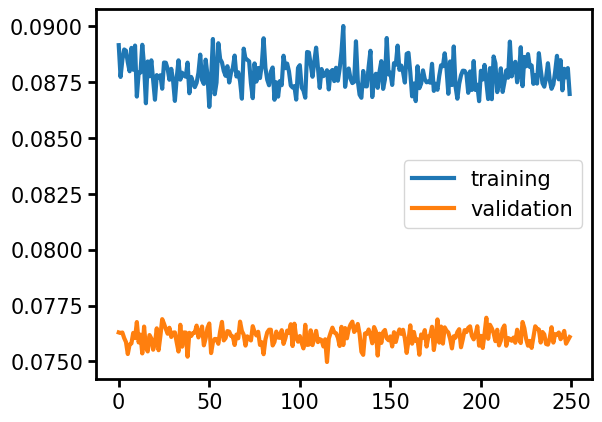

In [ ]:
plt.plot(train_loss_curve, label="training")
plt.plot(val_loss_curve, label="validation")
plt.legend()

**Task 2**: Now, report the *test* $R^2$ of your trained model on the test data, and visualize your prediction for train and test data with a scatter plot. You'll need to convert your prediction from `torch.Tensor` to `np.array` with `.cpu().detach().numpy()`, then compute the $R^2$ score with `sklearn.metrics.r2_score`.

In [ ]:
from sklearn.metrics import r2_score

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

########### Code #############
yhat_train = # Fill in
yhat_val = # Fill in
########### Code #############

yhat_train = yhat_train.cpu().detach().numpy()
yhat_val = yhat_val.cpu().detach().numpy()
ax[0].scatter(yhat_train, y_subtrain, label='Train', alpha=0.5)
ax[1].scatter(yhat_val, y_val, label='Test', alpha=0.5, c='orange')

ax[0].set_ylabel("True Binding Affinity")
ax[0].set_xlabel("Predicted Binding Affinity")
ax[1].set_xlabel("Predicted Binding Affinity")
ax[0].set_title('Train')
ax[1].set_title('Test')
fig.suptitle('Multi-Layer Perceptron')

print("Multi-Layer Perceptron training R^2 score: {:.2f}".format(r2_score(y_subtrain, yhat_train)))
print("Multi-Layer Perceptron testing R^2 score: {:.2f}".format((r2_score(y_val, yhat_val))))

**Question**: Finally, briefly comment on the `hidden_layers_sizes` values as they pertain to the MLP's intercepts and coefficients.

**Write answer here**

## 2.5 <span style="color:orange">(5 points) (grad)</span> Calculate model size

**Task 1**:
Calculate the number of parameters used in your MLP given the provided `hidden_layer_sizes`. You can do this manually or iterate over `model.parameters()`. Calculate the total of number of parameters in your MLP model.

In [ ]:
########## Answer ############

# You can retrieve the cofficients and compute the size

N_params = sum(p.numel() for p in model.parameters())
print("Total number of parameters: {} ".format(N_params))


# Or you can compute it by hand

N_input = 180
N_hid = [512, 256, 128]

N_params = N_input * N_hid[0] + N_hid[0]
for i, n_hid in enumerate(N_hid[:-1]):
    N_params += n_hid * (N_hid[i+1]) + N_hid[i+1]
N_params += N_hid[-1] + 1

print("Total number of parameters: {} ".format(N_params))

# For either method, the student can receive full credits.

########## Answer ############

**Question**: What does the input hidden_layers_sizes = (512, 256, 128) mean? What are the differences between hyperparametesr and learnable parameters? Provide examples of each.

**Write answer here**

## 2.6 <span style="color:blue">(5 points)</span> Chemical transferability of one-hot representations

We created a holdout/test set, which includes amino acids in new positions not seen in the training set, to test your model's performance.

**Task 1**: Load the holdout set and featurize the data with the label encoder from part 2.1. Validate your MLP by computing the $R^2$ score, and visualize your predictions with a scatter plot.

In [ ]:
# Load the holdout dataset which contains amino acids not seen in the training data
ba_holdout = pd.read_csv("ba_holdout.csv")

########### Code #############
# Your code to preprocess data and predict on this holdout dataset, including a scatterplot of predictions


# Encode holdout data with the predefined encoder
print("MLP validation R^2 score: {:.2f}".format(r2_score(y_holdout, yhat_holdout)))

########### Code #############

**Question**: Briefly describe your observations: does your model generalize well to this new data?

**Write answer here**

## 2.7 <span style="color:orange">(10 points) (grad)</span> Featurize amino acids with physical descriptors

Let's try using a more informative featurization, with physical descriptors of the amino acids. These physical descriptors were generated by the `peptide` package in Python and should provide physiochemical descriptions of various properties of amino acids.

**Task 1**: Load the data for physical descriptors stored in `amino_acid.csv` with the code we provided. Use all the numerical features to construct a new feature matrix; as you did for the one-hot features, construct your feature set by concatenating the individual amino acid features into a feature vector for the peptide. Split the data into a training (80%) set and a validation (20%) set; since we have continuous features again, rescale with `preprocessing.StandardScalar` as seen in Problem 1. Train on the training set with a MLP with the same hyperparameters we provided to you in part 2.6 (you will need to tweak the number of input features). Plot a scatterplot of predictions on the train and validation datasets.


In [ ]:
########### Code #############

amino_acid_df = pd.read_csv("amino_acid.csv")
amino_acid_df = amino_acid_df.set_index('Amino Acids')




########### Code #############

In [ ]:
########### Code #############
# new dataloaders needed
new_train_data = SequenceDataset(X_features_subtrain, y_features_subtrain)
new_train_dataloader = DataLoader(new_train_data, batch_size=batch_size, shuffle=True)

new_val_data = SequenceDataset(X_features_val, y_features_val)
new_val_dataloader = DataLoader(new_val_data, batch_size=batch_size, shuffle=True)

# Fill in the rest





print("Retrained MLP Training R^2 score: {:.2f}".format(r2_score(y_features_subtrain, yhat_new_train)))
print("Retrained MLP Validation R^2 score: {:.2f}".format(r2_score(y_features_val, yhat_new_val)))

########### Code #############

## 2.8 <span style="color:orange">(10 points) (grad)</span> Chemical transferability of physical descriptors

**Task 1**: Report the $R^2$ score on your holdout/test set using the model trained in the previous part and visualize your prediction with a scatter plot like you did before.

In [ ]:
########### Code #############



print("MLP holdout R^2 score: {:.2f}".format(r2_score(y_holdout, yhat_holdout)))

########### Code #############

**Question**: Has your prediction on the holdout set improved? Briefly explain why.

**Write answer here**

---

# Submission

Congratulations! You've reached the end of the pset. Please submit your completed work as a `.ipynb` to Gradescope. Furthermore, if you had any AI-based assistance or worked with collaborators, please list them in the following cell.

**For submission:**
Please take a look at the `# --- Configuration ---` section of the next cell. You will need to change the `NOTEBOOK_NAME` to match the name of your google colab notebook. After making the applicable changes, please run the cell which will reduce the size of your generated images and aim for a file size of less than 10 mb. Note that it will also delete cells tagged as "background", but you don't need to worry about it deleting your own code.

When successful, you'll be prompted to download the reformatted notebook which you can then upload to gradescope.

In [ ]:
import io
import os
import base64
import nbformat
import sys
from PIL import Image
from IPython.display import display, Javascript, HTML

# --- Configuration ---
NOTEBOOK_NAME = "ASSIGNMENT_NAME.ipynb" # The name of your file
OUTPUT_FILENAME = "submission.ipynb"
TAG_TO_REMOVE = "background"
MAX_IMG_WIDTH = 800
# Standard locations where Colab saves notebooks.
# IF YOU CHANGE THE LOCATION OF YOUR NOTEBOOK PLEASE ADD THE PATH HERE.
COLAB_PATHS = [
    f"/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}",
    f"/content/drive/MyDrive/{NOTEBOOK_NAME}"
]
# ---------------------

def get_input_path():
    """Determines the path of the notebook based on the environment."""
    if 'google.colab' in sys.modules:
        from google.colab import drive
        # 1. Mount Drive
        if not os.path.exists('/content/drive'):
            print("Mounting Google Drive to access the notebook file...")
            drive.mount('/content/drive')

        for path in COLAB_PATHS:
            if os.path.exists(path):
                return path

        # Fallback if not found
        print(f"\nERROR: Could not find '{NOTEBOOK_NAME}' in your Google Drive.")
        print("Please ensure the file is saved in 'My Drive' or 'Colab Notebooks'.")
        return None

    else:
        # Local Jupyter (runs in current directory)
        return NOTEBOOK_NAME

def resize_base64_image(b64_str, mime_type):
    # (Same resize logic as before - keeping it brief for readability)
    try:
        img_data = base64.b64decode(b64_str)
        img = Image.open(io.BytesIO(img_data))
        if img.width > MAX_IMG_WIDTH:
            ratio = MAX_IMG_WIDTH / img.width
            new_height = int(img.height * ratio)
            img = img.resize((MAX_IMG_WIDTH, new_height), Image.Resampling.LANCZOS)
            buf = io.BytesIO()
            fmt = 'PNG' if 'png' in mime_type else 'JPEG'
            img.save(buf, format=fmt, optimize=True)
            return base64.b64encode(buf.getvalue()).decode('utf-8')
        return b64_str
    except Exception as e:
        return b64_str

def generate_submission():
    # Trigger a save in the browser
    display(Javascript('IPython.notebook.save_checkpoint();'))

    input_path = get_input_path()
    if not input_path:
        return

    print(f"Reading notebook from: {input_path}")

    try:
        with open(input_path, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    new_cells = []

    # Filter Cells & Process Images
    for cell in nb.cells:
        tags = cell.get('metadata', {}).get('tags', [])
        tags = [t.lower() for t in tags] if tags else []
        if TAG_TO_REMOVE in tags:
            continue

        if 'outputs' in cell:
            for output in cell['outputs']:
                data = output.get('data', {})
                for mime_type in ['image/png', 'image/jpeg']:
                    if mime_type in data:
                        data[mime_type] = resize_base64_image(data[mime_type], mime_type)
        new_cells.append(cell)

    nb.cells = new_cells

    with open(OUTPUT_FILENAME, 'w', encoding='utf-8') as f:
        nbformat.write(nb, f)

    # Download logic for Colab
    if 'google.colab' in sys.modules:
        from google.colab import files
        print(f"Downloading {OUTPUT_FILENAME}...")
        files.download(OUTPUT_FILENAME)
        print(f"Success! {OUTPUT_FILENAME} downloaded.")
    else:
        print(f"Success! {OUTPUT_FILENAME} created.")
        display(HTML(f'<br/><a href="{OUTPUT_FILENAME}" download><b>Click here to download {OUTPUT_FILENAME}</b></a>'))

generate_submission()